In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!ln -s /content/gdrive/My\ Drive/ /mydrive

In [20]:
%cd /mydrive/yolo

/content/gdrive/My Drive/yolo


In [5]:
# download darknet folder - for windows use darknet of AlexeyAB and for linux download darknet of pjreddie
# uncomment the below line to download darknet folder. I already have so commented it

!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15909, done.
remote: Total 15909 (delta 0), reused 0 (delta 0), pack-reused 15909 (from 1)
Receiving objects: 100% (15909/15909), 14.42 MiB | 10.03 MiB/s, done.
Resolving deltas: 100% (10714/10714), done.
Updating files: 100% (2054/2054), done.


Changes to do in yolov4 architecture as per your dataset Open darknet folder -> cfg folder -> yolov4-tiny.cfg (Delete everything else)

change batch=1 from batch=64

change subdivisions=1 from subdivisions=16

width=608 #416 height=608 #416

Next is max_batches.This parameter is very very important.The thing to remember here is that minimum batch value would be 6000 ( if you have 1 class or 2 classes or 3 classes.)

#### In our case we have 4 classes. So max_batches would be 4*2000 = 8000 i.e 8000 would be the max_batches.

#### Steps are also important. There are 2 steps:Ist step should be 90% of the max_batch value. And 2nd step would be the 80% of the max_batch
#### steps are steps=7200,6400  (90% of 8000 and 80% of 8000)


Steps are also important. There are 2 steps:Ist step should be 90% of the max_batch value. And 2nd step would be the 80% of the max_batch steps are steps=5400,4800 (90% of 6000 and 80% of 6000)

We have 3 YOLO layers for 3 different scales.

Showing you a demo below. Just see the [Yolo] layer. Above [YOLO] layer, we have [convolutional] layer. Change the number of filters as per your output classes as per this calculation (classes+5)3 = (2+5)3 = 21

In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="UAKXx0syZcNtP6EhgKyI")
project = rf.workspace("cvproject-hd43l").project("people-mpod5-i1urw")
version = project.version(1)
dataset = version.download("darknet")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 129.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to people-1 in darknet:: 100%|██████████| 1392/1392 [00:10<00:00, 127.42it/s]


In [9]:
# Upload your dataset folder inside a data folder of darknet.

# Now let's dicide our dataset in train and tes using below script


import glob
import os
import numpy as np
import sys

current_dir = "/content/gdrive/MyDrive/yolo/people-1/train"
split_pct = 10;
file_train = open("darknet/data/train.txt", "w")
file_val = open("darknet/data/test.txt", "w")
counter = 1
index_test = round(100 / split_pct)
for pathAndFilename in glob.iglob(os.path.join(current_dir, "*.jpg")):
        title, ext = os.path.splitext(os.path.basename(pathAndFilename))
        if counter == index_test:
                counter = 1
                file_val.write(current_dir + "/" + title + '.jpg' + "\n")
        else:
                file_train.write(current_dir + "/" + title + '.jpg' + "\n")
                counter = counter + 1
file_train.close()
file_val.close()


In [ ]:
# Inside your data folder, you will train.txt and test.txt file now.
# Now create 2 files in data folder - obj.data and obj.names

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import os

def read_label(image_path):
  file_name = image_path.replace('.jpg', '.txt')
  with open(file_name, 'rt') as file:
    print(os.path.basename(file_name) + ': \n' + file.read())

image_path = glob.glob("darknet/data/obj/*.jpg")
fig = plt.figure(figsize=(12,8))
cols = 2
rows = 2
grid = gridspec.GridSpec(nrows=rows, ncols=cols, figure=fig)
for i in range(min(cols*rows, len(image_path))):
  fig.add_subplot(grid[i])
  image=plt.imread(image_path[i])
  plt.title(os.path.basename(image_path[i]))
  plt.axis(False)
  plt.imshow(image)
  read_label(image_path[i])

plt.savefig("dataset_examples.jpg", dpi=300)
plt.show()

<Figure size 1200x800 with 0 Axes>

In [21]:
pwd

'/content/gdrive/My Drive/yolo'

In [22]:
# Here we use transfer learning. Instead of training a model from scratch, we use pre-trained YOLOv4 weights
# Run the following command to download the YOLOv4 pre-trained weights file.
%cd darknet/data/

!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights

/content/gdrive/My Drive/yolo/darknet/data
--2025-12-05 15:38:30--  https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/75388965/228a9c00-3ea4-11eb-8e80-28d71569f56c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-05T16%3A38%3A04Z&rscd=attachment%3B+filename%3Dyolov4-tiny.weights&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-05T15%3A37%3A17Z&ske=2025-12-05T16%3A38%3A04Z&sks=b&skv=2018-11-09&sig=%2FJ%2F5X5MIOf1LFdUJYkx07yuy8eLs5ybZnjGYGazg5E0%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NDk1MDkxMSwibm

In [23]:
%cd ..

/content/gdrive/My Drive/yolo/darknet


In [14]:
#%cd darknet/
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile
!sed -i 's/LIBSO=0/LIBSO=1/' Makefile




In [15]:
# Install OpenCV development libraries
!apt-get update
!apt-get install -y libopencv-dev

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,842 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,571 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,196 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-

In [16]:
# Re-run make to compile Darknet after installing OpenCV
!make

mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -DCUDNN_HALF -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -DCUDNN_HALF -fPIC -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘void cv_draw_object(image, float*, int, int, int*, float*, int*, int, char**)’:
./src/image_opencv.cpp:1443:

In [17]:
!chmod +x ./darknet

In [24]:
!./darknet detector train data/obj.data cfg/yolov4-tiny-custom.cfg data/yolov4-tiny.weights -dont_show

Streaming output truncated to the last 5000 lines.
 total_bbox = 1563151, rewritten_bbox = 1.073601 % 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 30 Avg (IOU: 0.951444), count: 1, class_loss = 0.000047, iou_loss = 0.433647, total_loss = 0.433694 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 37 Avg (IOU: 0.000000), count: 1, class_loss = 0.000615, iou_loss = 0.000000, total_loss = 0.000615 
 total_bbox = 1563152, rewritten_bbox = 1.073600 % 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 30 Avg (IOU: 0.821065), count: 2, class_loss = 0.448484, iou_loss = 0.372695, total_loss = 0.821179 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 37 Avg (IOU: 0.000000), count: 1, class_loss = 0.000040, iou_loss = 0.000000, total_loss = 0.000040 
 total_bbox = 1563154, rewritten_bbox = 1.073599 % 
v3 (iou loss, Normalizer: (iou: 0.07, obj: 1.00, cls: 1.00) Region 30 Avg (IOU: 0.860578), count: 1, class_loss = 0.00181

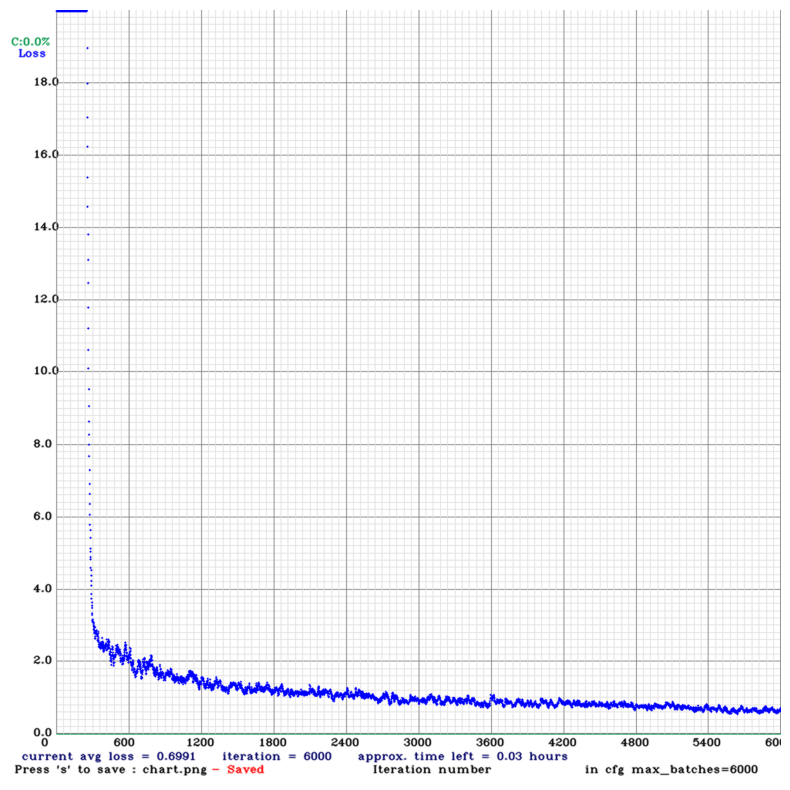

In [25]:
#can check the performance of all the trained weights by looking at the chart.png file. However, the chart.png file only shows results if the training does not get interrupted i.e. if you do not get disconnected or lose your session. If you restart training from a saved point, this will not work.
# define helper functions
def imShow(path):
  import cv2
  import matplotlib.pyplot as plt
  %matplotlib inline

  image = cv2.imread(path)
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  plt.show()
imShow('chart.png')

In [26]:
img_path = "data/person.jpg"
!./darknet detector test data/obj.data cfg/yolov4-tiny-custom_test.cfg data/yolov4-tiny-custom_final.weights {img_path} -dont-show

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
batch: Using default '1'
subdivisions: Using default '1'
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 1, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 2    416 x 416 x   3 ->  208 x 208 x  32 0.075 BF
   1 conv     64       3 x 3/ 2    208 x 208 x  32 ->  104 x 104 x  64 0.399 BF
   2 conv     64       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x  64 0.797 BF
   3 route  2 		                       1/2 ->  104 x 104 x  32 
   4 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   5 conv     32       3 x 3/ 1    104 x 104 x  32 ->  104 x 104 x  32 0.199 BF
   6 route  5 4 	                           ->  104 x 104 x  64 
   7 conv     64       1 x 1/ 1    104 x 104

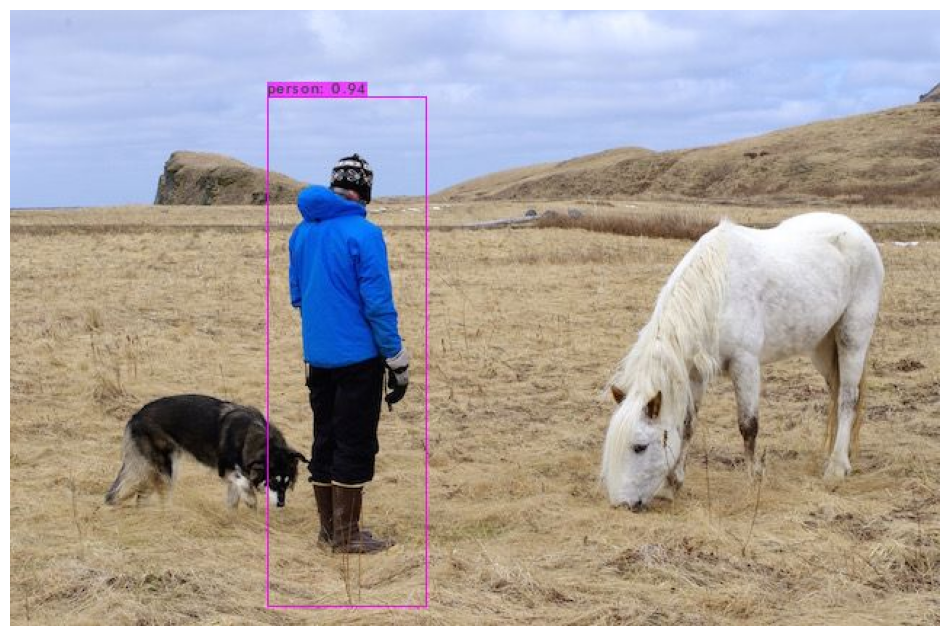

In [27]:

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12,12))
plt.axis(False)
processed_image = plt.imread("./predictions.jpg")
plt.imshow(processed_image)